<a href="https://colab.research.google.com/github/DEcoder1803/Emotion-Detection/blob/master/Emotion_detection_project_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://www.dropbox.com/s/nilt43hyl1dx82k/dataset.zip?dl=0

--2024-09-13 17:42:03--  https://www.dropbox.com/s/nilt43hyl1dx82k/dataset.zip?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/ied22o8pntppl24qr84vy/dataset.zip?rlkey=9e4cnwq83zhgrhw1g0zrkw275&dl=0 [following]
--2024-09-13 17:42:04--  https://www.dropbox.com/scl/fi/ied22o8pntppl24qr84vy/dataset.zip?rlkey=9e4cnwq83zhgrhw1g0zrkw275&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uca7dc6e6f7c8db8c52036dd47d3.dl.dropboxusercontent.com/cd/0/inline/Cai0uEBybm4cD_hCx26zDsNsRP5aCsckx6HClbkpZ8GqdikHrGRXIeDLcfLoux9nkXltVNlpXoZ_iG-edFY1nUlxWl3yVAAW17lhutoEhv2KHvEA14AqseXnMT7FHVOpFcT2DaWG9dMpmt4XJ-h_oPb7/file# [following]
--2024-09-13 17:42:05--  https://uca7dc6e6f7c8db8c52036dd47d3.dl.dropboxusercontent.com/c

In [ ]:
!unzip dataset.zip?dl=0

Archive:  dataset.zip?dl=0
replace test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.layers import Flatten, Dense
from keras.models import Model
# Instead of importing ImageDataGenerator, use this for image loading and preprocessing:
import tensorflow as tf # Import tensorflow
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.losses import categorical_crossentropy

In [ ]:
base_model = MobileNet( input_shape=(224,224,3), include_top= False )

for layer in base_model.layers:
  layer.trainable = False


x = Flatten()(base_model.output)
x = Dense(units=7 , activation='softmax' )(x)

# creating our model.
model = Model(base_model.input, x)

In [ ]:
model.compile(optimizer='adam', loss= categorical_crossentropy , metrics=['accuracy']  )

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.layers import Flatten, Dense
from keras.models import Model
# Instead of importing ImageDataGenerator, use this for image loading and preprocessing:
import tensorflow as tf # Import tensorflow
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.losses import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator from tensorflow.keras.preprocessing.image

train_datagen = ImageDataGenerator(
 zoom_range = 0.2,
 shear_range = 0.2,
 horizontal_flip=True,
 rescale = 1./255
)

train_data = train_datagen.flow_from_directory(directory= "/content/train",
                                               target_size=(224,224),
                                               batch_size=32,
                                  )


train_data.class_indices

Found 28709 images belonging to 7 classes.


{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [ ]:
val_datagen = ImageDataGenerator(rescale = 1./255 )

val_data = val_datagen.flow_from_directory(directory= "/content/test",
                                           target_size=(224,224),
                                           batch_size=32,
                                  )

Found 7178 images belonging to 7 classes.


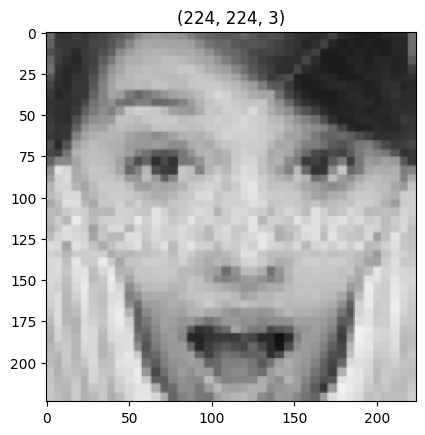

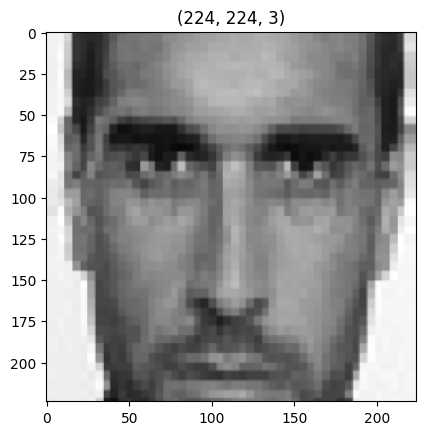

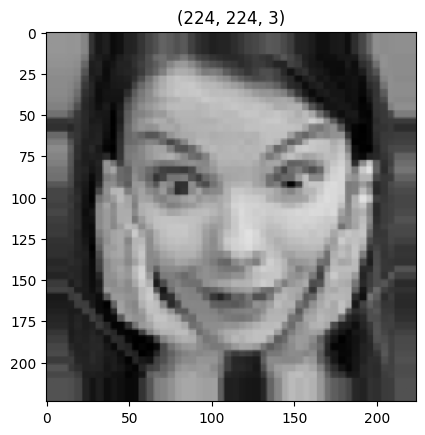

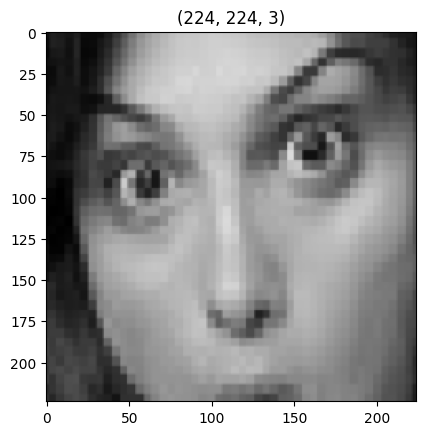

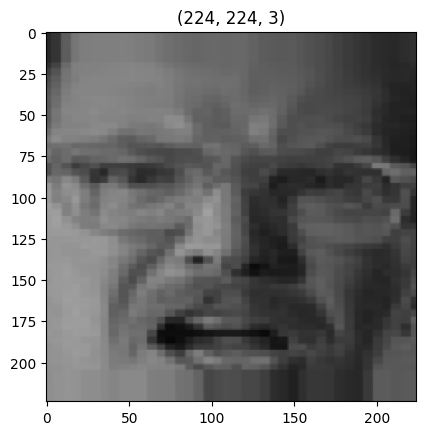

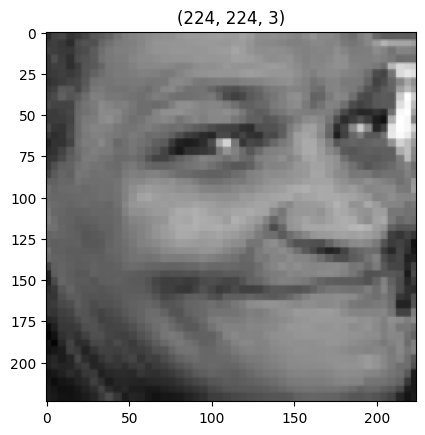

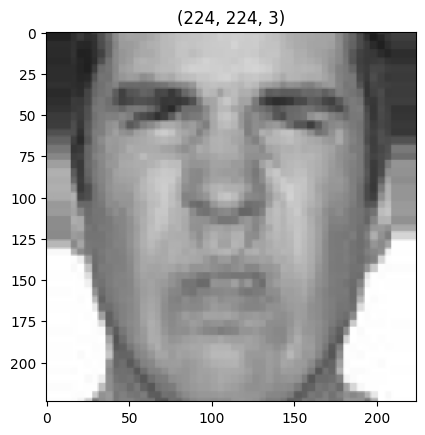

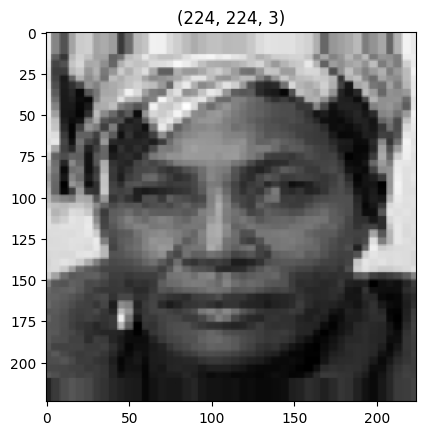

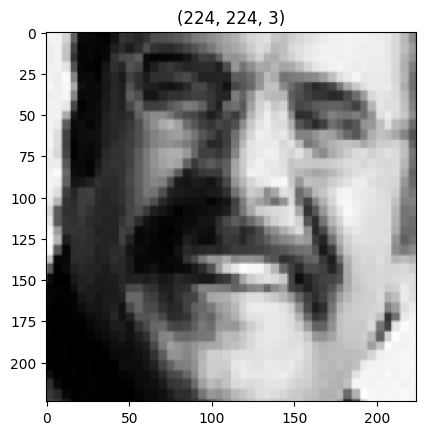

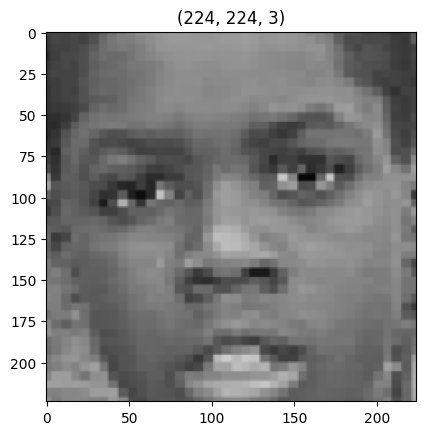

In [ ]:
t_img , label = next(train_data) # Use next(train_data) to get the next batch of data

#-----------------------------------------------------------------------------
# function when called will prot the images
def plotImages(img_arr, label):
  """
  input  :- images array
  output :- plots the images
  """
  count = 0
  for im, l in zip(img_arr,label) :
    plt.imshow(im)
    plt.title(im.shape)
    plt.axis = False
    plt.show()

    count += 1
    if count == 10:
      break

#-----------------------------------------------------------------------------
# function call to plot the images
plotImages(t_img, label)

In [ ]:
## having early stopping and model check point

from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta= 0.01 , patience= 5, verbose= 1, mode='auto')

# model check point
mc = ModelCheckpoint(filepath="best_model.keras", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto') # Changed the file extension to .keras

# puting call back in a list
call_back = [es, mc]

In [ ]:
hist = model.fit(train_data, # Use fit instead of fit_generator
                           steps_per_epoch= 10,
                           epochs= 30,
                           validation_data= val_data,
                           validation_steps= 8,
                           callbacks=[es,mc])

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3678 - loss: 5.0839
Epoch 1: val_accuracy improved from -inf to 0.42188, saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.3704 - loss: 5.0904 - val_accuracy: 0.4219 - val_loss: 6.0835
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4023 - loss: 6.1924
Epoch 2: val_accuracy did not improve from 0.42188
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4001 - loss: 6.2085 - val_accuracy: 0.3555 - val_loss: 8.1628
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4071 - loss: 5.4389
Epoch 3: val_accuracy improved from 0.42188 to 0.46875, saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4076 - loss: 5.4200 - val_accuracy: 0.4688 - val_loss: 5.1313
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3996 - loss: 5.8363
Epoch 4: val_accuracy did not improve from 0.46875
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accur

In [ ]:
from keras.models import load_model
model = load_model("/content/best_model.keras") # Changed filename to best_model.keras

In [ ]:
h =  hist.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

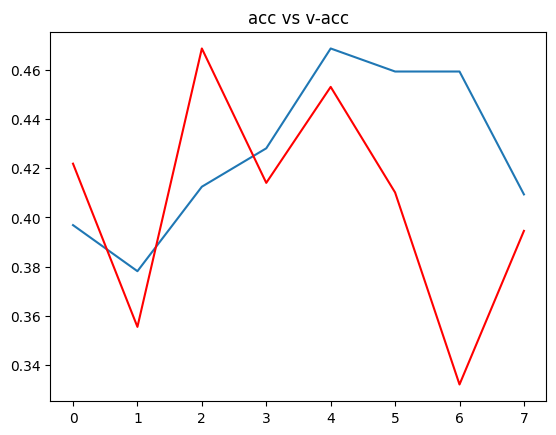

In [ ]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

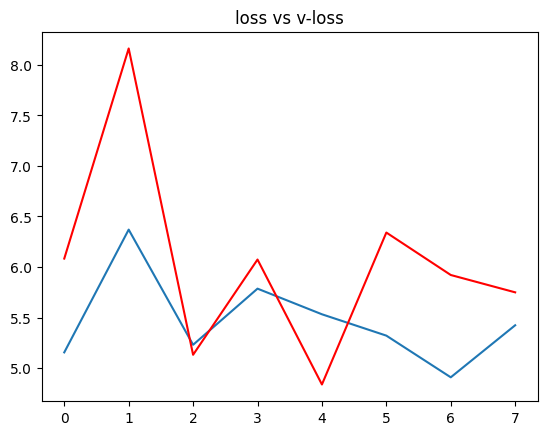

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:
op = dict(zip( train_data.class_indices.values(), train_data.class_indices.keys()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
 the image is of happy


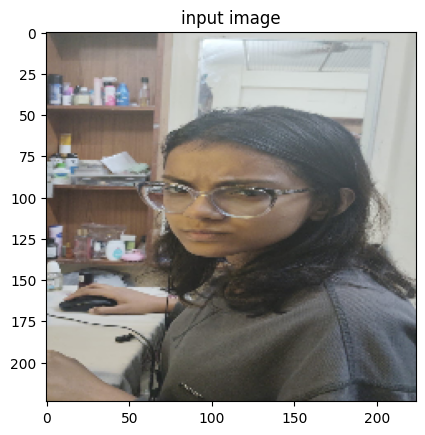

In [ ]:
from tensorflow.keras.utils import load_img # import the load_img function
from tensorflow.keras.utils import img_to_array
import numpy as np
import matplotlib.pyplot as plt


path = "/content/drita.jpg"
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

# Assuming 'model' is defined elsewhere in your code
pred = np.argmax(model.predict(input_arr))

# Assuming 'op' (output dictionary) is defined elsewhere in your code
print(f" the image is of {op[pred]}")

# to display the image
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()